# Pi0 Hacking Notebook Part 7 — PyTorch Version

Same exploration as the JAX notebook, but using the PyTorch implementation for easier tracing.
The PyTorch model lets us hook into individual layers, set breakpoints, and inspect activations
without fighting `nn.scan` or the NNX bridge.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from PIL import Image
import copy
import math
import time

import torch
import torch.nn.functional as F

# openpi imports
from openpi.training import config as _config
from openpi.policies import policy_config as _policy_config
from openpi.policies import aloha_policy
from openpi.shared import download
from openpi import transforms as _transforms
from openpi.shared import normalize as _normalize
from openpi.models import model as _model

print("Imports OK")

Imports OK


In [2]:
joint_labels = [
    "L joint 0 (waist)", "L joint 1 (shoulder)", "L joint 2 (elbow)",
    "L joint 3 (forearm)", "L joint 4 (wrist angle)", "L joint 5 (wrist rotate)",
    "L gripper",
    "R joint 0 (waist)", "R joint 1 (shoulder)", "R joint 2 (elbow)",
    "R joint 3 (forearm)", "R joint 4 (wrist angle)", "R joint 5 (wrist rotate)",
    "R gripper",
]

In [3]:
def frame_to_obs(frame):
    """Convert a HuggingFace dataset frame to the observation dict
    that the policy expects (post-RepackTransform format)."""
    def to_chw(img):
        arr = np.array(img)  # PIL -> HWC (H, W, 3)
        return arr.transpose(2, 0, 1)  # -> CHW (3, H, W)
    
    return {
        "images": {
            "cam_high": to_chw(frame["observation.images.cam_high"]),
            "cam_left_wrist": to_chw(frame["observation.images.cam_left_wrist"]),
            "cam_right_wrist": to_chw(frame["observation.images.cam_right_wrist"]),
        },
        "state": np.array(frame["observation.state"]),
        "prompt": "uncap the pen",
    }

## 1. Load Dataset

In [4]:
ds = load_dataset("physical-intelligence/aloha_pen_uncap_diverse", split="train")
print(f"Total rows: {len(ds)}")
print(f"Columns: {ds.column_names}")
print(f"Episode indices: {sorted(set(ds['episode_index']))}")

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/123 [00:00<?, ?it/s]

Total rows: 36900
Columns: ['observation.state', 'action', 'observation.velocity', 'observation.effort', 'observation.images.cam_high', 'observation.images.cam_low', 'observation.images.cam_left_wrist', 'observation.images.cam_right_wrist', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']
Episode indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122]


In [5]:
# Pick an episode and grab all its frames
EPISODE_IDX = 0

ep_indices = np.array(ds["episode_index"])
mask = ep_indices == EPISODE_IDX
row_indices = np.where(mask)[0]
episode = ds.select(row_indices)

In [6]:
# Pick a frame in the middle of the episode
FRAME_IDX = 150
frame = episode[FRAME_IDX]

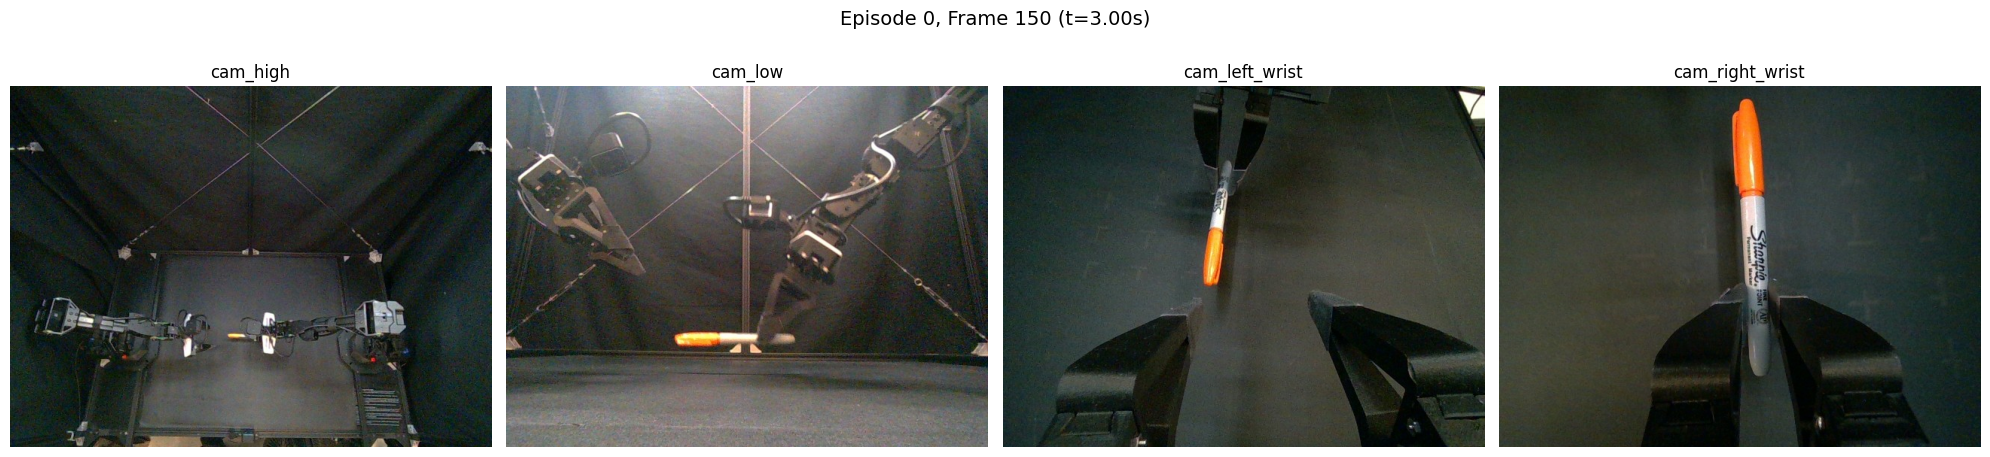

In [7]:
# Display camera views
cam_names = ["cam_high", "cam_low", "cam_left_wrist", "cam_right_wrist"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, cam_names):
    img = frame[f"observation.images.{name}"]
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.suptitle(f"Episode {EPISODE_IDX}, Frame {FRAME_IDX} (t={frame['timestamp']:.2f}s)", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Load PyTorch Model

In [8]:
config = _config.get_config("pi0_aloha_pen_uncap")

# Point to converted PyTorch checkpoint
checkpoint_dir = "/home/stephen/robots/openpi/pi0_aloha_pen_uncap_pytorch"

print(f"Model type: {config.model.model_type}")
print(f"Action dim: {config.model.action_dim}")
print(f"Action horizon: {config.model.action_horizon}")

Model type: ModelType.PI0
Action dim: 32
Action horizon: 50


In [9]:
# Create the trained policy — auto-detects PyTorch format
policy = _policy_config.create_trained_policy(config, checkpoint_dir)
print(f"Policy created successfully!")
print(f"PyTorch model: {policy._is_pytorch_model}")
print(f"Device: {policy._pytorch_device}")
print(f"Number of input transforms: {len(policy._input_transform.transforms)}")
print(f"Number of output transforms: {len(policy._output_transform.transforms)}")

Policy created successfully!
PyTorch model: True
Device: cuda
Number of input transforms: 8
Number of output transforms: 3


In [10]:
# Quick reference inference to make sure the model works
obs_test = frame_to_obs(frame)
result_test = policy.infer(obs_test)
print(f"Actions shape: {result_test['actions'].shape}")
print(f"Inference time: {result_test['policy_timing']['infer_ms']:.1f} ms")

Actions shape: (50, 14)
Inference time: 24290.8 ms


## 3. Reference Inference with Fixed Noise

Generate fixed noise (using numpy so we don't need JAX at all),
run `policy.infer` as a black box, and save the result as our reference.

In [11]:
# Fix noise for reproducibility (numpy, no JAX dependency)
rng = np.random.RandomState(42)
fixed_noise = rng.randn(50, 32).astype(np.float32)
print(f"fixed_noise: {fixed_noise.shape}, dtype={fixed_noise.dtype}")
print(f"  norm={np.linalg.norm(fixed_noise):.4f}, mean={fixed_noise.mean():.4f}")

# Reference result using policy.infer as a black box
obs_ref = frame_to_obs(frame)
result_ref = policy.infer(obs_ref, noise=fixed_noise)
print(f"\nReference actions: {result_ref['actions'].shape}")
print(f"  range: [{result_ref['actions'].min():.4f}, {result_ref['actions'].max():.4f}]")

fixed_noise: (50, 32), dtype=float32
  norm=39.7640, mean=0.0398

Reference actions: (50, 14)
  range: [-0.4732, 1.1151]


## 4. Manual Reproduction — Input Transforms

Replicate what `policy.infer()` does step by step.

In [12]:
device = torch.device(policy._pytorch_device)
pt_model = policy._model  # the PI0Pytorch instance
print(f"Device: {device}")
print(f"Model type: {type(pt_model).__name__}")

Device: cuda
Model type: PI0Pytorch


In [13]:
# Step 1: Input transforms (same chain as JAX version)
obs_manual = frame_to_obs(frame)
inputs = policy._input_transform(obs_manual)

print("After input transforms:")
for k, v in inputs.items():
    if isinstance(v, dict):
        for k2, v2 in v.items():
            print(f"  {k}/{k2}: {v2.shape}, dtype={v2.dtype}")
    elif isinstance(v, np.ndarray):
        print(f"  {k}: {v.shape}, dtype={v.dtype}")
    else:
        print(f"  {k}: {type(v)}")

After input transforms:
  image/base_0_rgb: (224, 224, 3), dtype=uint8
  image/left_wrist_0_rgb: (224, 224, 3), dtype=uint8
  image/right_wrist_0_rgb: (224, 224, 3), dtype=uint8
  image_mask/base_0_rgb: (), dtype=bool
  image_mask/left_wrist_0_rgb: (), dtype=bool
  image_mask/right_wrist_0_rgb: (), dtype=bool
  state: (32,), dtype=float64
  tokenized_prompt: (48,), dtype=int64
  tokenized_prompt_mask: (48,), dtype=bool


In [14]:
# Step 2: Batch and convert to PyTorch tensors — each leaf [shape] -> torch [1, shape]
import jax  # just for tree.map utility, no JAX computation
inputs_pt = jax.tree.map(
    lambda x: torch.from_numpy(np.array(x)).to(device)[None, ...],
    inputs
)

print("Batched PyTorch tensors:")
for k, v in inputs_pt.items():
    if isinstance(v, dict):
        for k2, v2 in v.items():
            print(f"  {k}/{k2}: {v2.shape}, dtype={v2.dtype}, device={v2.device}")
    elif isinstance(v, torch.Tensor):
        print(f"  {k}: {v.shape}, dtype={v.dtype}")

Batched PyTorch tensors:
  image/base_0_rgb: torch.Size([1, 224, 224, 3]), dtype=torch.uint8, device=cuda:0
  image/left_wrist_0_rgb: torch.Size([1, 224, 224, 3]), dtype=torch.uint8, device=cuda:0
  image/right_wrist_0_rgb: torch.Size([1, 224, 224, 3]), dtype=torch.uint8, device=cuda:0
  image_mask/base_0_rgb: torch.Size([1]), dtype=torch.bool, device=cuda:0
  image_mask/left_wrist_0_rgb: torch.Size([1]), dtype=torch.bool, device=cuda:0
  image_mask/right_wrist_0_rgb: torch.Size([1]), dtype=torch.bool, device=cuda:0
  state: torch.Size([1, 32]), dtype=torch.float64
  tokenized_prompt: torch.Size([1, 48]), dtype=torch.int64
  tokenized_prompt_mask: torch.Size([1, 48]), dtype=torch.bool


In [15]:
# Step 3: Build Observation dataclass
# For torch uint8 images, from_dict converts to float32 and permutes to BCHW
observation = _model.Observation.from_dict(inputs_pt)

print("Observation:")
for name, img in observation.images.items():
    print(f"  image[{name}]: {img.shape}, dtype={img.dtype}, range=[{img.min():.2f}, {img.max():.2f}]")
for name, m in observation.image_masks.items():
    print(f"  mask[{name}]: {m.shape}, dtype={m.dtype}")
print(f"  state: {observation.state.shape}, dtype={observation.state.dtype}")
print(f"  tokenized_prompt: {observation.tokenized_prompt.shape}")
print(f"  tokenized_prompt_mask: {observation.tokenized_prompt_mask.shape}, valid={observation.tokenized_prompt_mask.sum()}")

Observation:
  image[base_0_rgb]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 0.99]
  image[left_wrist_0_rgb]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 1.00]
  image[right_wrist_0_rgb]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 1.00]
  mask[base_0_rgb]: torch.Size([1]), dtype=torch.bool
  mask[left_wrist_0_rgb]: torch.Size([1]), dtype=torch.bool
  mask[right_wrist_0_rgb]: torch.Size([1]), dtype=torch.bool
  state: torch.Size([1, 32]), dtype=torch.float64
  tokenized_prompt: torch.Size([1, 48])
  tokenized_prompt_mask: torch.Size([1, 48]), valid=6


## 5. Preprocess + Embed Prefix

Now we enter the model internals. The PyTorch model's `_preprocess_observation`
handles image resizing, then `embed_prefix` runs SigLIP on images and embeds language tokens.

In [16]:
# Step 4: Preprocess observation (no augmentation at inference)
# This unpacks the Observation into lists that embed_prefix expects
images, img_masks, lang_tokens, lang_masks, state = pt_model._preprocess_observation(
    observation, train=False
)

print("Preprocessed observation:")
for i, (img, mask) in enumerate(zip(images, img_masks)):
    print(f"  image[{i}]: {img.shape}, dtype={img.dtype}, range=[{img.min():.2f}, {img.max():.2f}]")
    print(f"  mask[{i}]:  {mask.shape}, val={mask}")
print(f"  lang_tokens: {lang_tokens.shape}, dtype={lang_tokens.dtype}")
print(f"  lang_masks: {lang_masks.shape}, valid={lang_masks.sum()}")
print(f"  state: {state.shape}, dtype={state.dtype}")

Preprocessed observation:
  image[0]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 0.99]
  mask[0]:  torch.Size([1]), val=tensor([True], device='cuda:0')
  image[1]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 1.00]
  mask[1]:  torch.Size([1]), val=tensor([True], device='cuda:0')
  image[2]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 1.00]
  mask[2]:  torch.Size([1]), val=tensor([True], device='cuda:0')
  lang_tokens: torch.Size([1, 48]), dtype=torch.int64
  lang_masks: torch.Size([1, 48]), valid=6
  state: torch.Size([1, 32]), dtype=torch.float64


In [17]:
# Step 5: Embed prefix using model's embed_prefix method
with torch.no_grad():
    prefix_embs, prefix_pad_masks, prefix_att_masks = pt_model.embed_prefix(
        images, img_masks, lang_tokens, lang_masks
    )

print(f"prefix_embs:      {prefix_embs.shape}, dtype={prefix_embs.dtype}")      # [1, 816, 2048]
print(f"prefix_pad_masks: {prefix_pad_masks.shape}, dtype={prefix_pad_masks.dtype}")  # [1, 816]
print(f"prefix_att_masks: {prefix_att_masks.shape}, dtype={prefix_att_masks.dtype}")  # [1, 816]

prefix_embs:      torch.Size([1, 816, 2048]), dtype=torch.bfloat16
prefix_pad_masks: torch.Size([1, 816]), dtype=torch.bool
prefix_att_masks: torch.Size([1, 816]), dtype=torch.bool


### 5b. Expand embed_prefix manually

Let's do what `embed_prefix` does, but step by step so we can inspect each piece.
This is much easier to trace than the JAX version!

In [18]:
with torch.no_grad():
    embs_list = []
    pad_mask_list = []
    ar_mask_list = []

    # --- Encode each image through SigLIP ---
    # In PyTorch: paligemma.model.get_image_features
    # This is HuggingFace's PaliGemma vision tower (SigLIP So400m/14)
    for i, (img, img_mask) in enumerate(zip(images, img_masks)):
        img_emb = pt_model.paligemma_with_expert.embed_image(img)
        bsize, num_img_tokens = img_emb.shape[:2]

        print(f"SigLIP image {i}:")
        print(f"  input:  {img.shape}, dtype={img.dtype}, range=[{img.min():.2f}, {img.max():.2f}]")
        print(f"  output: {img_emb.shape}, dtype={img_emb.dtype}")

        embs_list.append(img_emb)
        pad_mask_list.append(img_mask[:, None].expand(bsize, num_img_tokens))
        ar_mask_list += [0] * num_img_tokens

    # --- Embed language tokens ---
    # PaliGemma's embedding table + scale by sqrt(dim)
    lang_emb = pt_model.paligemma_with_expert.embed_language_tokens(lang_tokens)
    lang_emb_dim = lang_emb.shape[-1]
    lang_emb = lang_emb * math.sqrt(lang_emb_dim)

    print(f"\nLanguage embedding:")
    print(f"  token IDs: {lang_tokens.shape}, non-padding: {lang_masks.sum()}")
    print(f"  embeddings: {lang_emb.shape}, dtype={lang_emb.dtype}")

    embs_list.append(lang_emb)
    pad_mask_list.append(lang_masks)
    ar_mask_list += [0] * lang_emb.shape[1]

    # --- Concatenate into full prefix sequence ---
    prefix_embs_manual = torch.cat(embs_list, dim=1)
    prefix_pad_masks_manual = torch.cat(pad_mask_list, dim=1)

    print(f"\nFull prefix:")
    print(f"  embs:      {prefix_embs_manual.shape}  (3x256 image + 48 language = 816)")
    print(f"  pad_masks: {prefix_pad_masks_manual.shape}  (valid: {prefix_pad_masks_manual.sum()})")

    # --- Compare against reference ---
    max_diff = (prefix_embs_manual - prefix_embs).abs().max().item()
    print(f"\nMax diff vs embed_prefix reference: {max_diff}")

SigLIP image 0:
  input:  torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 0.99]
  output: torch.Size([1, 256, 2048]), dtype=torch.bfloat16
SigLIP image 1:
  input:  torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 1.00]
  output: torch.Size([1, 256, 2048]), dtype=torch.bfloat16
SigLIP image 2:
  input:  torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 1.00]
  output: torch.Size([1, 256, 2048]), dtype=torch.bfloat16

Language embedding:
  token IDs: torch.Size([1, 48]), non-padding: 6
  embeddings: torch.Size([1, 48, 2048]), dtype=torch.bfloat16

Full prefix:
  embs:      torch.Size([1, 816, 2048])  (3x256 image + 48 language = 816)
  pad_masks: torch.Size([1, 816])  (valid: 774)

Max diff vs embed_prefix reference: 0.0


In [19]:
# pt_model.paligemma_with_expert.embed_image?
# pt_model.paligemma_with_expert.model.get_image_features

In [20]:
# pt_model.paligemma_with_expert.paligemma.model.get_image_features

In [21]:
lang_tokens

tensor([[   2,  549, 5549,  573, 3008,  108,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0]],
       device='cuda:0')

In [22]:
# from transformers import AutoTokenizer

# tokenizer = AutoTokenizer.from_pretrained("google/paligemma-3b-pt-224")

# # Decode the full sequence
# print(tokenizer.decode(lang_tokens[0]))

# # See individual tokens (including padding)
# tokens = tokenizer.convert_ids_to_tokens(lang_tokens[0].tolist())
# for i, (tok, mask) in enumerate(zip(tokens, lang_masks[0])):
#     print(f"  [{i:2d}] id={lang_tokens[0, i]:6d}  mask={mask.item()}  '{tok}'")

## 6. Prefix Forward Pass → KV Cache

Run the prefix tokens through the PaliGemma language model (18 layers) and cache the K, V.
This is the `[prefix_embs, None]` call — only expert 0 (PaliGemma) runs.

In [23]:
from openpi.models_pytorch.pi0_pytorch import make_att_2d_masks

with torch.no_grad():
    # Build attention mask
    prefix_att_2d = make_att_2d_masks(prefix_pad_masks, prefix_att_masks)
    prefix_positions = torch.cumsum(prefix_pad_masks, dim=1) - 1

    print(f"prefix_att_2d: {prefix_att_2d.shape}")  # [1, 816, 816]
    print(f"prefix_positions: {prefix_positions.shape}")  # [1, 816]

    # Convert to 4D attention mask (the format HuggingFace expects)
    prefix_att_4d = pt_model._prepare_attention_masks_4d(prefix_att_2d)
    print(f"prefix_att_4d: {prefix_att_4d.shape}")  # [1, 1, 816, 816]

    # Set eager attention (not SDPA) so we can hook into it
    pt_model.paligemma_with_expert.paligemma.language_model.config._attn_implementation = "eager"

    # Forward pass: [prefix_embs, None] — only PaliGemma runs, action expert gets None
    _, kv_cache = pt_model.paligemma_with_expert.forward(
        attention_mask=prefix_att_4d,
        position_ids=prefix_positions,
        past_key_values=None,
        inputs_embeds=[prefix_embs, None],
        use_cache=True,
    )

print(f"\nKV cache type: {type(kv_cache).__name__}")
print(f"KV cache layers: {len(kv_cache)}")
# Each layer has (key, value) tensors
k0, v0 = kv_cache[0]
print(f"Layer 0 K: {k0.shape}, V: {v0.shape}")  # [1, num_kv_heads, 816, head_dim]

prefix_att_2d: torch.Size([1, 816, 816])
prefix_positions: torch.Size([1, 816])
prefix_att_4d: torch.Size([1, 1, 816, 816])

KV cache type: DynamicCache
KV cache layers: 18
Layer 0 K: torch.Size([1, 1, 816, 256]), V: torch.Size([1, 1, 816, 256])


In [24]:
prefix_att_4d.shape

torch.Size([1, 1, 816, 816])

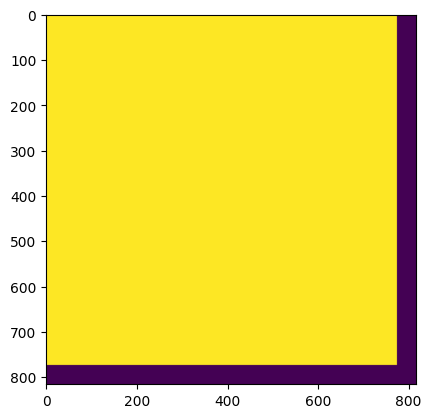

In [25]:
plt.imshow(prefix_att_4d[0,0].detach().cpu().numpy())

- Right so not the diagonal attention mask we would see in autoregressive text generation
- Hmm i would like to visualize some attention patterns!

In [26]:
pt_model.paligemma_with_expert

PaliGemmaWithExpertModel(
  (paligemma): PaliGemmaForConditionalGeneration(
    (model): PaliGemmaModel(
      (vision_tower): SiglipVisionModel(
        (vision_model): SiglipVisionTransformer(
          (embeddings): SiglipVisionEmbeddings(
            (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
            (position_embedding): Embedding(256, 1152)
          )
          (encoder): SiglipEncoder(
            (layers): ModuleList(
              (0-26): 27 x SiglipEncoderLayer(
                (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
                (self_attn): SiglipAttention(
                  (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
      

In [27]:
# pt_model.paligemma_with_expert?

In [28]:
state.shape

torch.Size([1, 32])

In [29]:
state

tensor([[-0.2073, -0.0050, -0.8066, -0.6117, -1.2639,  0.4968,  0.7046, -0.1185,
         -0.7430, -0.0498,  0.0678, -0.8378, -0.4027, -1.2744,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000]],
       device='cuda:0', dtype=torch.float64)

In [30]:
# x_t.shape

In [31]:
# x_t

## 7. Flow Matching Denoising Loop

10 Euler steps from t=1 (noise) to t=0 (actions).
Each step embeds the suffix (state + noisy actions + timestep), runs the action expert
with the cached prefix KV, and takes an Euler step.

Jump in here and viz attention patterns before first denoising step

In [33]:
num_steps = 10
dt = -1.0 / num_steps

# Start from fixed noise
noise_pt = torch.from_numpy(fixed_noise).to(device)[None, ...]  # [1, 50, 32]
x_t = noise_pt.clone()

# Collect trajectory for visualization
trajectory = [x_t[0].cpu().numpy().copy()]
velocities = []
t = 1.0

In [34]:
expert_attn_patterns = {}
hooks = []

def make_expert_attn_hook(layer_idx):
    def hook_fn(module, inp, out):
        if isinstance(out, tuple) and len(out) >= 2 and out[1] is not None:
            expert_attn_patterns[layer_idx] = out[1].detach().cpu()
    return hook_fn

expert_layers = pt_model.paligemma_with_expert.gemma_expert.model.layers
for i, layer in enumerate(expert_layers):
    h = layer.self_attn.register_forward_hook(make_expert_attn_hook(i))
    hooks.append(h)

# Make sure eager attention is set (otherwise weights may be None)
pt_model.paligemma_with_expert.gemma_expert.model.config._attn_implementation = "eager"

# Run one denoising step at t=1.0 (first step, pure noise)
with torch.no_grad():
    timestep = torch.tensor([1.0], dtype=torch.float32, device=device)
    v_t = pt_model.denoise_step(
        state, prefix_pad_masks, kv_cache, noise_pt, timestep
    )

for h in hooks:
    h.remove()

print(f"Captured {len(expert_attn_patterns)} layers")
for layer_idx in sorted(expert_attn_patterns.keys()):
    attn = expert_attn_patterns[layer_idx]
    print(f"  layer {layer_idx}: {attn.shape}")
    # Expecting [1, 8, 51, 867] — 51 suffix queries attending to 816 prefix + 51 suffix

Captured 18 layers
  layer 0: torch.Size([1, 8, 51, 867])
  layer 1: torch.Size([1, 8, 51, 867])
  layer 2: torch.Size([1, 8, 51, 867])
  layer 3: torch.Size([1, 8, 51, 867])
  layer 4: torch.Size([1, 8, 51, 867])
  layer 5: torch.Size([1, 8, 51, 867])
  layer 6: torch.Size([1, 8, 51, 867])
  layer 7: torch.Size([1, 8, 51, 867])
  layer 8: torch.Size([1, 8, 51, 867])
  layer 9: torch.Size([1, 8, 51, 867])
  layer 10: torch.Size([1, 8, 51, 867])
  layer 11: torch.Size([1, 8, 51, 867])
  layer 12: torch.Size([1, 8, 51, 867])
  layer 13: torch.Size([1, 8, 51, 867])
  layer 14: torch.Size([1, 8, 51, 867])
  layer 15: torch.Size([1, 8, 51, 867])
  layer 16: torch.Size([1, 8, 51, 867])
  layer 17: torch.Size([1, 8, 51, 867])


Attention shape: torch.Size([51, 867])
  Columns 0-815: prefix (3x256 image + 48 language)
  Columns 816-866: suffix (1 state + 50 action)


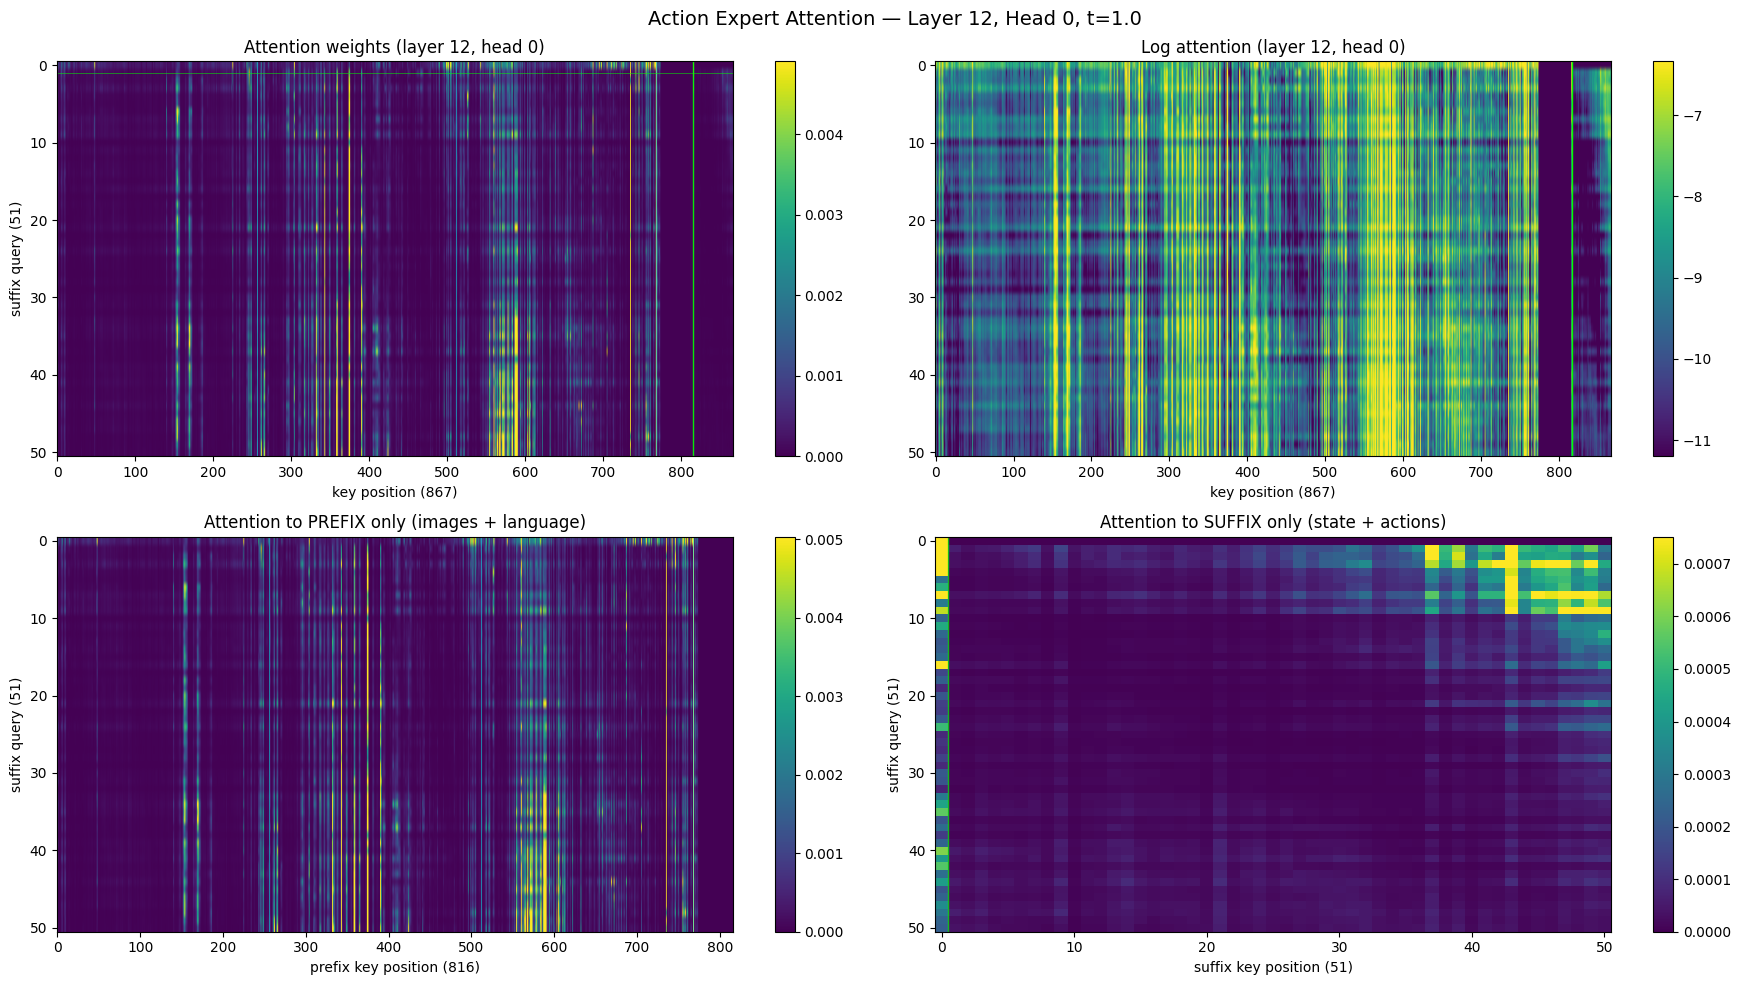

In [36]:
layer_idx = 12
head = 0

attn = expert_attn_patterns[layer_idx][0, head].float()
log_attn = torch.log(attn + 1e-10)

print(f"Attention shape: {attn.shape}")  # [51, 867]
print(f"  Columns 0-815: prefix (3x256 image + 48 language)")
print(f"  Columns 816-866: suffix (1 state + 50 action)")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# --- Top left: full attention pattern ---
im0 = axes[0, 0].imshow(attn.numpy(), cmap='viridis', aspect='auto',
                          vmin=0, vmax=attn.quantile(0.99).item())
axes[0, 0].set_title(f"Attention weights (layer {layer_idx}, head {head})")
axes[0, 0].set_ylabel("suffix query (51)")
axes[0, 0].set_xlabel("key position (867)")
axes[0, 0].axvline(x=256, color='cyan', linewidth=0.5, alpha=0.7, label='img boundaries')
axes[0, 0].axvline(x=512, color='cyan', linewidth=0.5, alpha=0.7)
axes[0, 0].axvline(x=768, color='cyan', linewidth=0.5, alpha=0.7, label='img/lang boundary')
axes[0, 0].axvline(x=816, color='lime', linewidth=1.0, alpha=0.9, label='prefix/suffix boundary')
axes[0, 0].axhline(y=1, color='lime', linewidth=0.5, alpha=0.7, label='state/action boundary')
plt.colorbar(im0, ax=axes[0, 0])

# --- Top right: log attention (more dynamic range) ---
im1 = axes[0, 1].imshow(log_attn.numpy(), cmap='viridis', aspect='auto',
                          vmin=log_attn[log_attn > -20].quantile(0.05).item(),
                          vmax=log_attn[log_attn > -20].quantile(0.95).item())
axes[0, 1].set_title(f"Log attention (layer {layer_idx}, head {head})")
axes[0, 1].set_xlabel("key position (867)")
axes[0, 1].axvline(x=816, color='lime', linewidth=1.0)
plt.colorbar(im1, ax=axes[0, 1])

# --- Bottom left: attention to prefix only (where is the expert looking in the images/language?) ---
prefix_attn = attn[:, :816].numpy()
im2 = axes[1, 0].imshow(prefix_attn, cmap='viridis', aspect='auto',
                          vmin=0, vmax=np.quantile(prefix_attn, 0.99))
axes[1, 0].set_title("Attention to PREFIX only (images + language)")
axes[1, 0].set_ylabel("suffix query (51)")
axes[1, 0].set_xlabel("prefix key position (816)")
for boundary in [256, 512, 768]:
    axes[1, 0].axvline(x=boundary, color='cyan', linewidth=0.5, alpha=0.7)
plt.colorbar(im2, ax=axes[1, 0])

# --- Bottom right: attention to suffix only (state + action self-attention) ---
suffix_attn = attn[:, 816:].numpy()
im3 = axes[1, 1].imshow(suffix_attn, cmap='viridis', aspect='auto',
                          vmin=0, vmax=np.quantile(suffix_attn, 0.99))
axes[1, 1].set_title("Attention to SUFFIX only (state + actions)")
axes[1, 1].set_ylabel("suffix query (51)")
axes[1, 1].set_xlabel("suffix key position (51)")
axes[1, 1].axvline(x=0.5, color='lime', linewidth=1.0, alpha=0.7, label='state token')
plt.colorbar(im3, ax=axes[1, 1])

plt.suptitle(f"Action Expert Attention — Layer {layer_idx}, Head {head}, t=1.0", fontsize=14)
plt.tight_layout()
plt.show()

Attention shape: torch.Size([51, 867])
  Columns 0-815: prefix (3x256 image + 48 language)
  Columns 816-866: suffix (1 state + 50 action)


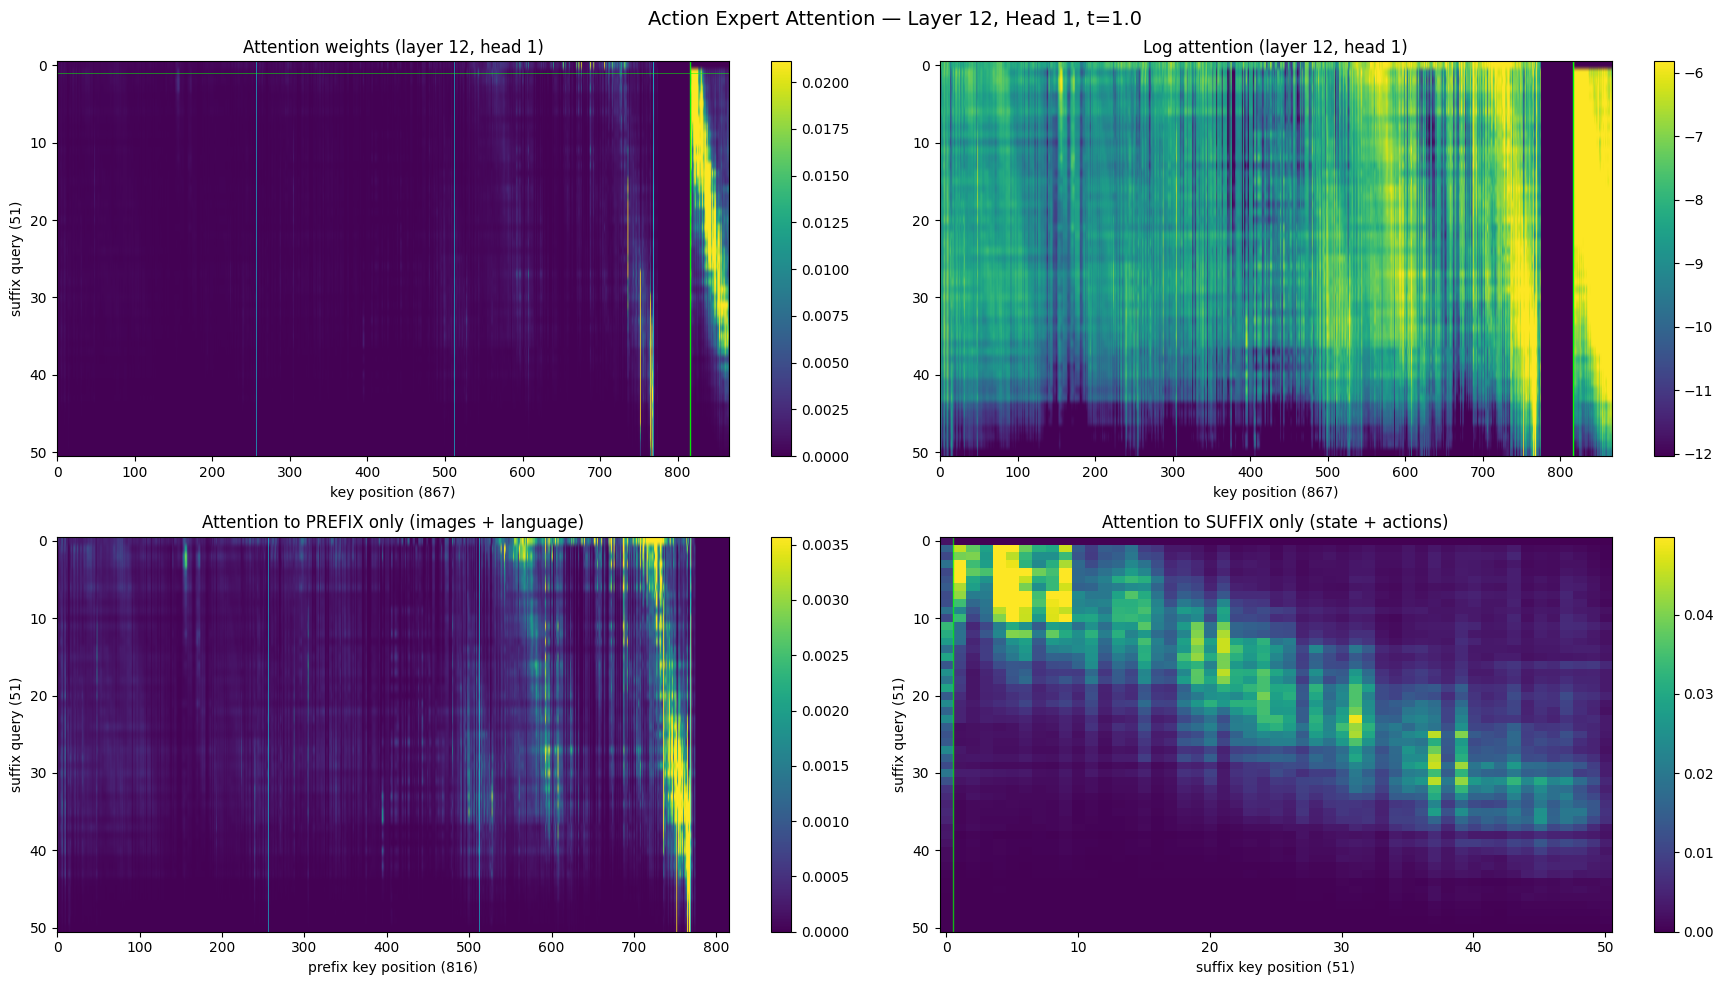

In [38]:
layer_idx = 12
head = 1

attn = expert_attn_patterns[layer_idx][0, head].float()
log_attn = torch.log(attn + 1e-10)

print(f"Attention shape: {attn.shape}")  # [51, 867]
print(f"  Columns 0-815: prefix (3x256 image + 48 language)")
print(f"  Columns 816-866: suffix (1 state + 50 action)")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# --- Top left: full attention pattern ---
im0 = axes[0, 0].imshow(attn.numpy(), cmap='viridis', aspect='auto',
                          vmin=0, vmax=attn.quantile(0.99).item())
axes[0, 0].set_title(f"Attention weights (layer {layer_idx}, head {head})")
axes[0, 0].set_ylabel("suffix query (51)")
axes[0, 0].set_xlabel("key position (867)")
axes[0, 0].axvline(x=256, color='cyan', linewidth=0.5, alpha=0.7, label='img boundaries')
axes[0, 0].axvline(x=512, color='cyan', linewidth=0.5, alpha=0.7)
axes[0, 0].axvline(x=768, color='cyan', linewidth=0.5, alpha=0.7, label='img/lang boundary')
axes[0, 0].axvline(x=816, color='lime', linewidth=1.0, alpha=0.9, label='prefix/suffix boundary')
axes[0, 0].axhline(y=1, color='lime', linewidth=0.5, alpha=0.7, label='state/action boundary')
plt.colorbar(im0, ax=axes[0, 0])

# --- Top right: log attention (more dynamic range) ---
im1 = axes[0, 1].imshow(log_attn.numpy(), cmap='viridis', aspect='auto',
                          vmin=log_attn[log_attn > -20].quantile(0.05).item(),
                          vmax=log_attn[log_attn > -20].quantile(0.95).item())
axes[0, 1].set_title(f"Log attention (layer {layer_idx}, head {head})")
axes[0, 1].set_xlabel("key position (867)")
axes[0, 1].axvline(x=816, color='lime', linewidth=1.0)
plt.colorbar(im1, ax=axes[0, 1])

# --- Bottom left: attention to prefix only (where is the expert looking in the images/language?) ---
prefix_attn = attn[:, :816].numpy()
im2 = axes[1, 0].imshow(prefix_attn, cmap='viridis', aspect='auto',
                          vmin=0, vmax=np.quantile(prefix_attn, 0.99))
axes[1, 0].set_title("Attention to PREFIX only (images + language)")
axes[1, 0].set_ylabel("suffix query (51)")
axes[1, 0].set_xlabel("prefix key position (816)")
for boundary in [256, 512, 768]:
    axes[1, 0].axvline(x=boundary, color='cyan', linewidth=0.5, alpha=0.7)
plt.colorbar(im2, ax=axes[1, 0])

# --- Bottom right: attention to suffix only (state + action self-attention) ---
suffix_attn = attn[:, 816:].numpy()
im3 = axes[1, 1].imshow(suffix_attn, cmap='viridis', aspect='auto',
                          vmin=0, vmax=np.quantile(suffix_attn, 0.99))
axes[1, 1].set_title("Attention to SUFFIX only (state + actions)")
axes[1, 1].set_ylabel("suffix query (51)")
axes[1, 1].set_xlabel("suffix key position (51)")
axes[1, 1].axvline(x=0.5, color='lime', linewidth=1.0, alpha=0.7, label='state token')
plt.colorbar(im3, ax=axes[1, 1])

plt.suptitle(f"Action Expert Attention — Layer {layer_idx}, Head {head}, t=1.0", fontsize=14)
plt.tight_layout()
plt.show()

This one is kind aintersting! Defintiely feels like it's "looking at something"

Attention shape: torch.Size([51, 867])
  Columns 0-815: prefix (3x256 image + 48 language)
  Columns 816-866: suffix (1 state + 50 action)


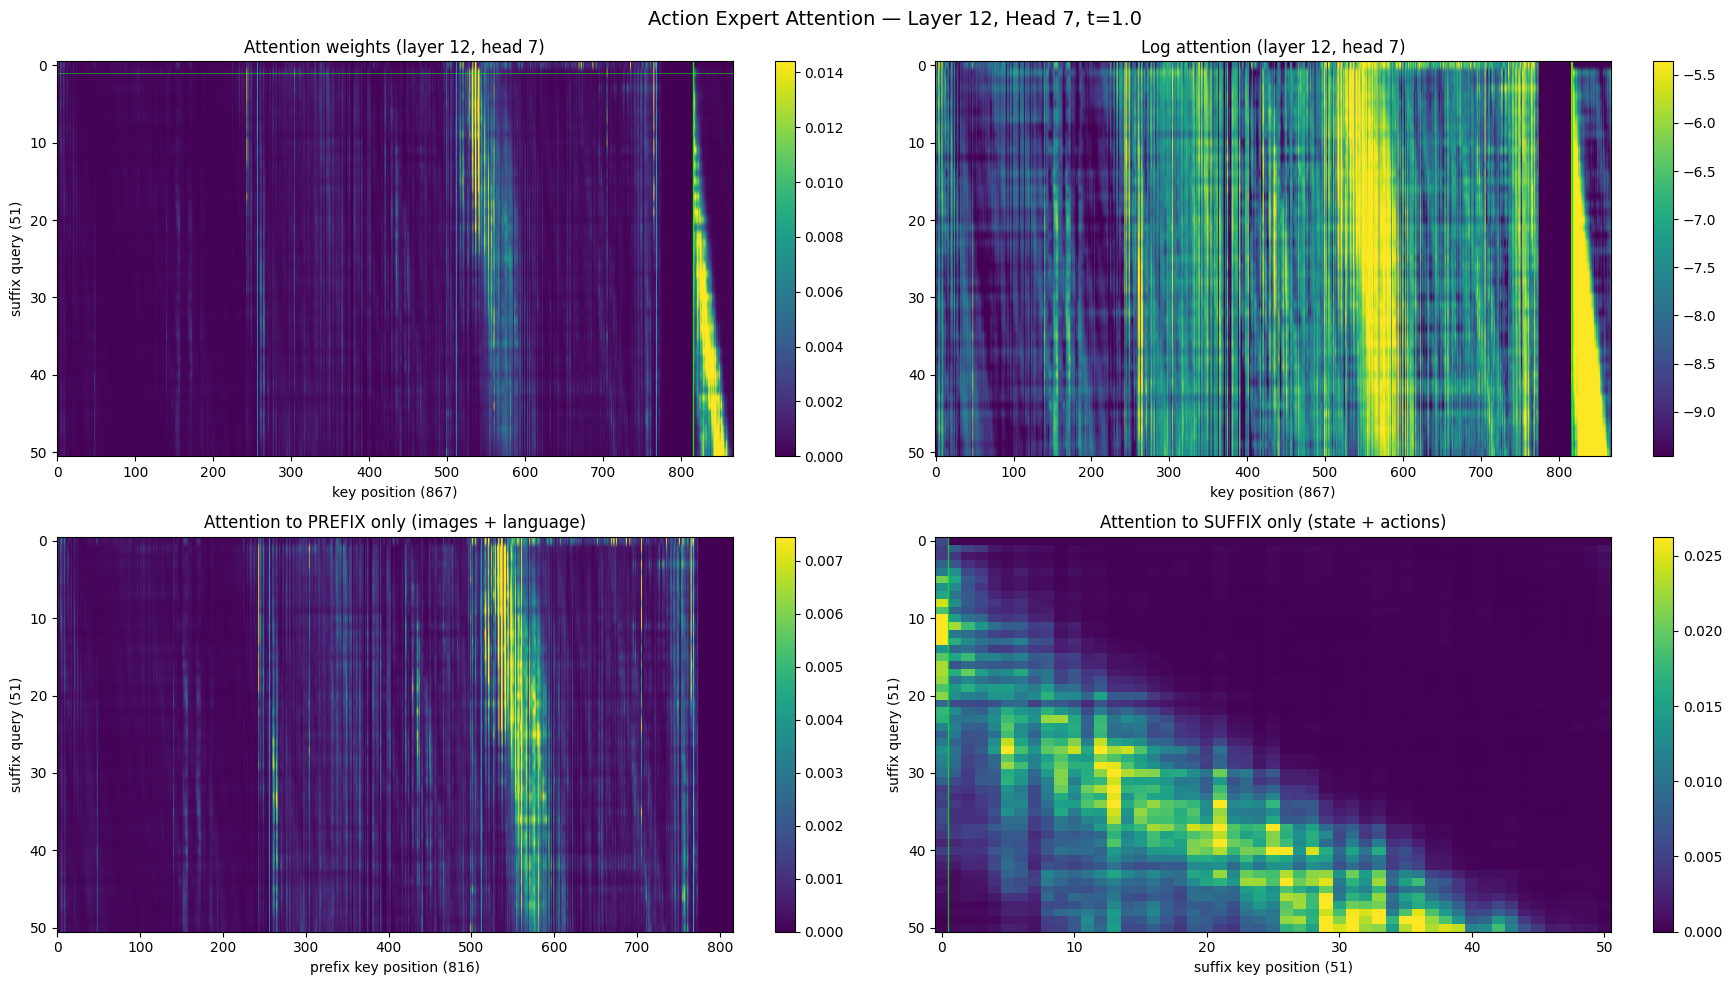

In [45]:
layer_idx = 12
head = 7

attn = expert_attn_patterns[layer_idx][0, head].float()
log_attn = torch.log(attn + 1e-10)

print(f"Attention shape: {attn.shape}")  # [51, 867]
print(f"  Columns 0-815: prefix (3x256 image + 48 language)")
print(f"  Columns 816-866: suffix (1 state + 50 action)")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# --- Top left: full attention pattern ---
im0 = axes[0, 0].imshow(attn.numpy(), cmap='viridis', aspect='auto',
                          vmin=0, vmax=attn.quantile(0.99).item())
axes[0, 0].set_title(f"Attention weights (layer {layer_idx}, head {head})")
axes[0, 0].set_ylabel("suffix query (51)")
axes[0, 0].set_xlabel("key position (867)")
axes[0, 0].axvline(x=256, color='cyan', linewidth=0.5, alpha=0.7, label='img boundaries')
axes[0, 0].axvline(x=512, color='cyan', linewidth=0.5, alpha=0.7)
axes[0, 0].axvline(x=768, color='cyan', linewidth=0.5, alpha=0.7, label='img/lang boundary')
axes[0, 0].axvline(x=816, color='lime', linewidth=1.0, alpha=0.9, label='prefix/suffix boundary')
axes[0, 0].axhline(y=1, color='lime', linewidth=0.5, alpha=0.7, label='state/action boundary')
plt.colorbar(im0, ax=axes[0, 0])

# --- Top right: log attention (more dynamic range) ---
im1 = axes[0, 1].imshow(log_attn.numpy(), cmap='viridis', aspect='auto',
                          vmin=log_attn[log_attn > -20].quantile(0.05).item(),
                          vmax=log_attn[log_attn > -20].quantile(0.95).item())
axes[0, 1].set_title(f"Log attention (layer {layer_idx}, head {head})")
axes[0, 1].set_xlabel("key position (867)")
axes[0, 1].axvline(x=816, color='lime', linewidth=1.0)
plt.colorbar(im1, ax=axes[0, 1])

# --- Bottom left: attention to prefix only (where is the expert looking in the images/language?) ---
prefix_attn = attn[:, :816].numpy()
im2 = axes[1, 0].imshow(prefix_attn, cmap='viridis', aspect='auto',
                          vmin=0, vmax=np.quantile(prefix_attn, 0.99))
axes[1, 0].set_title("Attention to PREFIX only (images + language)")
axes[1, 0].set_ylabel("suffix query (51)")
axes[1, 0].set_xlabel("prefix key position (816)")
for boundary in [256, 512, 768]:
    axes[1, 0].axvline(x=boundary, color='cyan', linewidth=0.5, alpha=0.7)
plt.colorbar(im2, ax=axes[1, 0])

# --- Bottom right: attention to suffix only (state + action self-attention) ---
suffix_attn = attn[:, 816:].numpy()
im3 = axes[1, 1].imshow(suffix_attn, cmap='viridis', aspect='auto',
                          vmin=0, vmax=np.quantile(suffix_attn, 0.99))
axes[1, 1].set_title("Attention to SUFFIX only (state + actions)")
axes[1, 1].set_ylabel("suffix query (51)")
axes[1, 1].set_xlabel("suffix key position (51)")
axes[1, 1].axvline(x=0.5, color='lime', linewidth=1.0, alpha=0.7, label='state token')
plt.colorbar(im3, ax=axes[1, 1])

plt.suptitle(f"Action Expert Attention — Layer {layer_idx}, Head {head}, t=1.0", fontsize=14)
plt.tight_layout()
plt.show()

Attention shape: torch.Size([51, 867])
  Columns 0-815: prefix (3x256 image + 48 language)
  Columns 816-866: suffix (1 state + 50 action)


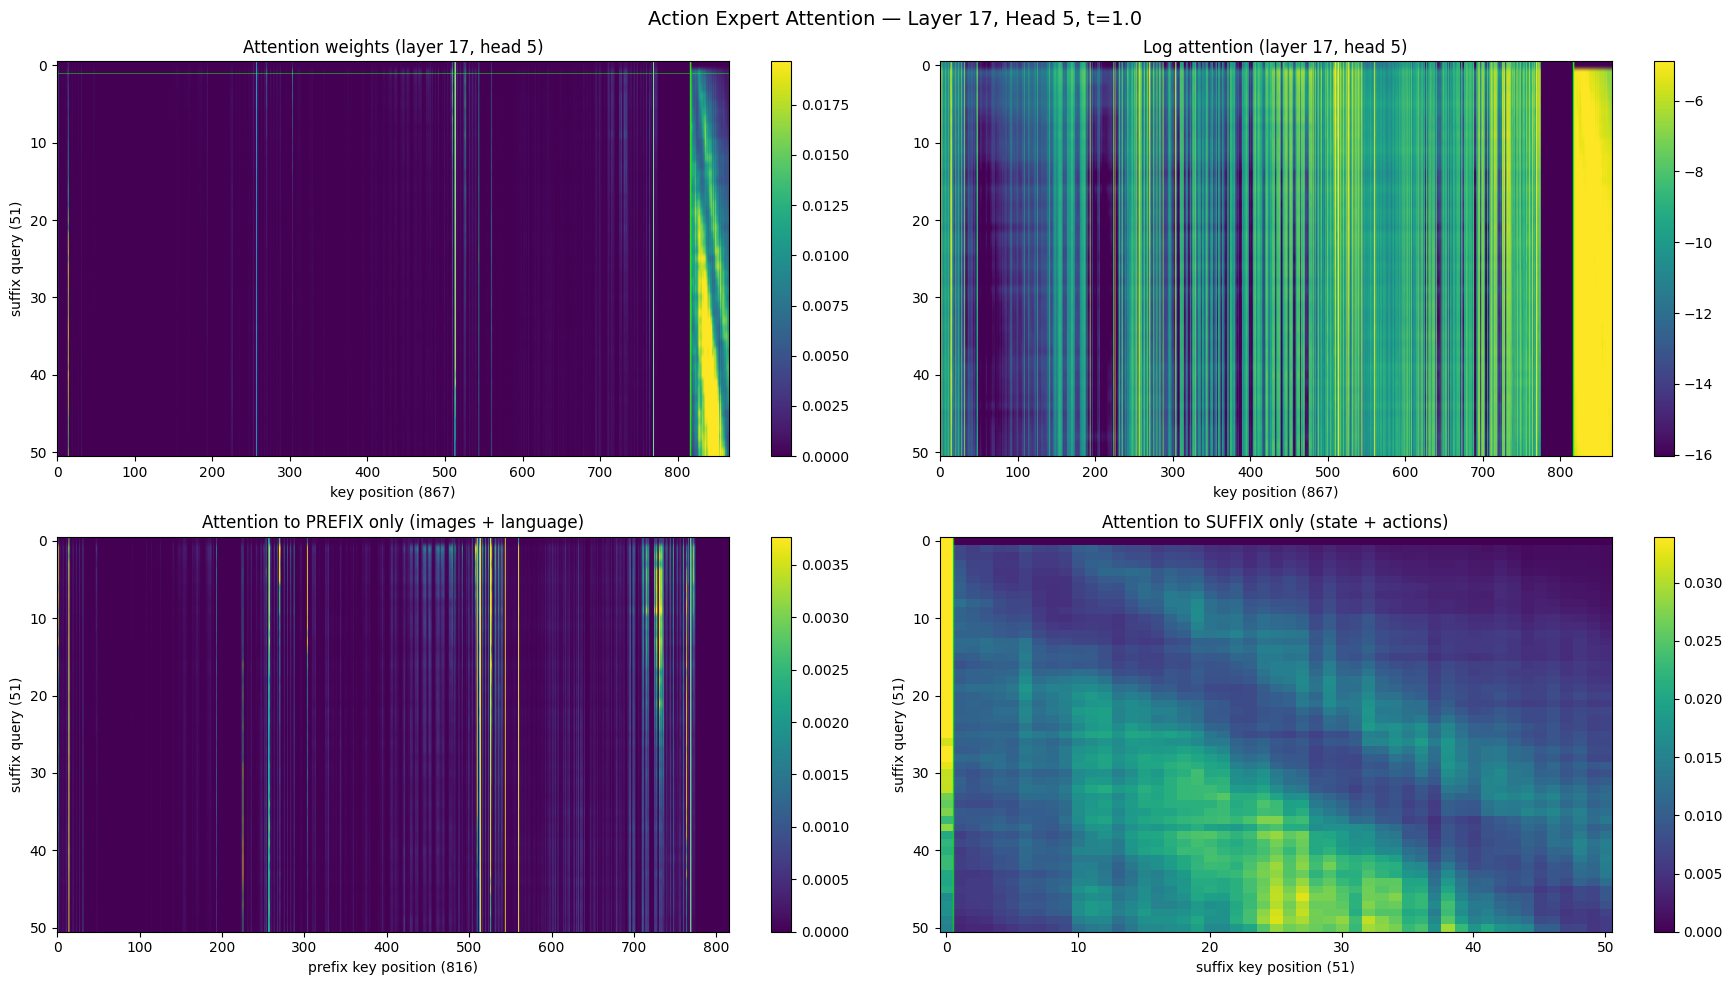

In [50]:
layer_idx =17
head = 5

attn = expert_attn_patterns[layer_idx][0, head].float()
log_attn = torch.log(attn + 1e-10)

print(f"Attention shape: {attn.shape}")  # [51, 867]
print(f"  Columns 0-815: prefix (3x256 image + 48 language)")
print(f"  Columns 816-866: suffix (1 state + 50 action)")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# --- Top left: full attention pattern ---
im0 = axes[0, 0].imshow(attn.numpy(), cmap='viridis', aspect='auto',
                          vmin=0, vmax=attn.quantile(0.99).item())
axes[0, 0].set_title(f"Attention weights (layer {layer_idx}, head {head})")
axes[0, 0].set_ylabel("suffix query (51)")
axes[0, 0].set_xlabel("key position (867)")
axes[0, 0].axvline(x=256, color='cyan', linewidth=0.5, alpha=0.7, label='img boundaries')
axes[0, 0].axvline(x=512, color='cyan', linewidth=0.5, alpha=0.7)
axes[0, 0].axvline(x=768, color='cyan', linewidth=0.5, alpha=0.7, label='img/lang boundary')
axes[0, 0].axvline(x=816, color='lime', linewidth=1.0, alpha=0.9, label='prefix/suffix boundary')
axes[0, 0].axhline(y=1, color='lime', linewidth=0.5, alpha=0.7, label='state/action boundary')
plt.colorbar(im0, ax=axes[0, 0])

# --- Top right: log attention (more dynamic range) ---
im1 = axes[0, 1].imshow(log_attn.numpy(), cmap='viridis', aspect='auto',
                          vmin=log_attn[log_attn > -20].quantile(0.05).item(),
                          vmax=log_attn[log_attn > -20].quantile(0.95).item())
axes[0, 1].set_title(f"Log attention (layer {layer_idx}, head {head})")
axes[0, 1].set_xlabel("key position (867)")
axes[0, 1].axvline(x=816, color='lime', linewidth=1.0)
plt.colorbar(im1, ax=axes[0, 1])

# --- Bottom left: attention to prefix only (where is the expert looking in the images/language?) ---
prefix_attn = attn[:, :816].numpy()
im2 = axes[1, 0].imshow(prefix_attn, cmap='viridis', aspect='auto',
                          vmin=0, vmax=np.quantile(prefix_attn, 0.99))
axes[1, 0].set_title("Attention to PREFIX only (images + language)")
axes[1, 0].set_ylabel("suffix query (51)")
axes[1, 0].set_xlabel("prefix key position (816)")
for boundary in [256, 512, 768]:
    axes[1, 0].axvline(x=boundary, color='cyan', linewidth=0.5, alpha=0.7)
plt.colorbar(im2, ax=axes[1, 0])

# --- Bottom right: attention to suffix only (state + action self-attention) ---
suffix_attn = attn[:, 816:].numpy()
im3 = axes[1, 1].imshow(suffix_attn, cmap='viridis', aspect='auto',
                          vmin=0, vmax=np.quantile(suffix_attn, 0.99))
axes[1, 1].set_title("Attention to SUFFIX only (state + actions)")
axes[1, 1].set_ylabel("suffix query (51)")
axes[1, 1].set_xlabel("suffix key position (51)")
axes[1, 1].axvline(x=0.5, color='lime', linewidth=1.0, alpha=0.7, label='state token')
plt.colorbar(im3, ax=axes[1, 1])

plt.suptitle(f"Action Expert Attention — Layer {layer_idx}, Head {head}, t=1.0", fontsize=14)
plt.tight_layout()
plt.show()

Last layer is kinda cool!

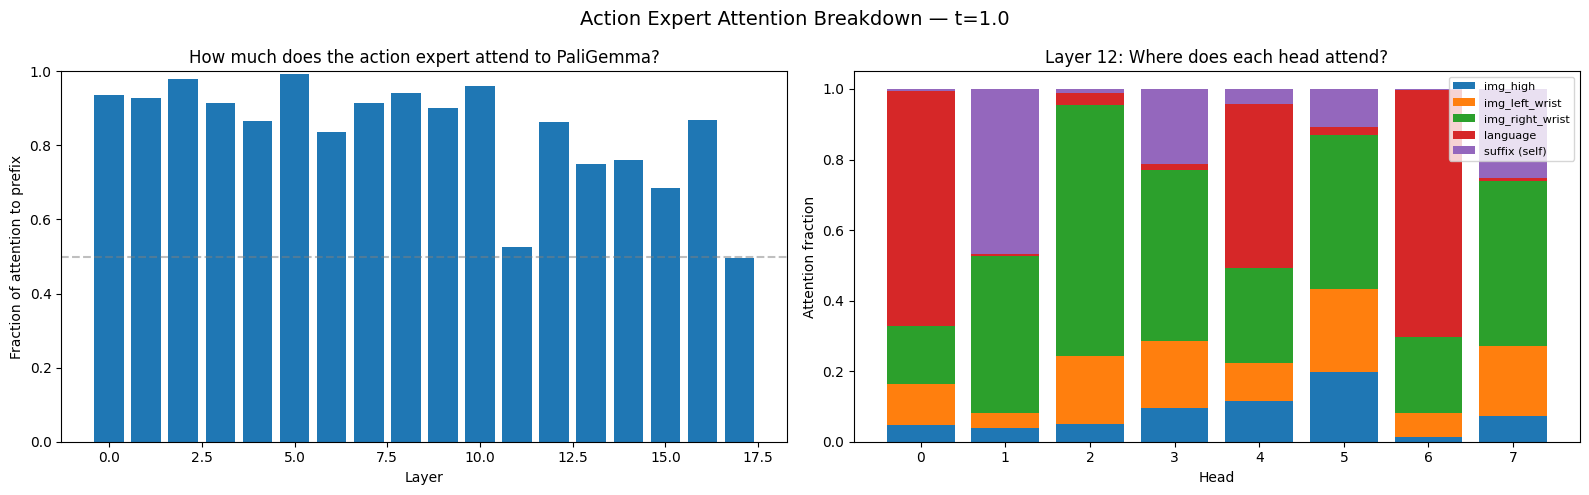

In [37]:
# For each layer and head: what fraction of attention goes to prefix vs suffix?
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Per-layer breakdown (averaged over heads and queries)
prefix_frac_by_layer = []
for layer_idx in range(18):
    attn = expert_attn_patterns[layer_idx][0].float()  # [8, 51, 867]
    to_prefix = attn[:, :, :816].sum(dim=-1).mean().item()  # avg attention mass on prefix
    prefix_frac_by_layer.append(to_prefix)

axes[0].bar(range(18), prefix_frac_by_layer)
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Fraction of attention to prefix")
axes[0].set_title("How much does the action expert attend to PaliGemma?")
axes[0].set_ylim(0, 1)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# Per-head breakdown at a specific layer
layer_idx = 12
attn = expert_attn_patterns[layer_idx][0].float()  # [8, 51, 867]
for head in range(8):
    head_attn = attn[head]  # [51, 867]
    to_img1 = head_attn[:, :256].sum(dim=-1).mean().item()
    to_img2 = head_attn[:, 256:512].sum(dim=-1).mean().item()
    to_img3 = head_attn[:, 512:768].sum(dim=-1).mean().item()
    to_lang = head_attn[:, 768:816].sum(dim=-1).mean().item()
    to_suffix = head_attn[:, 816:].sum(dim=-1).mean().item()
    
    axes[1].bar(head, to_img1, color='tab:blue', label='img_high' if head == 0 else '')
    axes[1].bar(head, to_img2, bottom=to_img1, color='tab:orange', label='img_left_wrist' if head == 0 else '')
    axes[1].bar(head, to_img3, bottom=to_img1+to_img2, color='tab:green', label='img_right_wrist' if head == 0 else '')
    axes[1].bar(head, to_lang, bottom=to_img1+to_img2+to_img3, color='tab:red', label='language' if head == 0 else '')
    axes[1].bar(head, to_suffix, bottom=to_img1+to_img2+to_img3+to_lang, color='tab:purple', label='suffix (self)' if head == 0 else '')

axes[1].set_xlabel("Head")
axes[1].set_ylabel("Attention fraction")
axes[1].set_title(f"Layer {layer_idx}: Where does each head attend?")
axes[1].legend(loc='upper right', fontsize=8)

plt.suptitle("Action Expert Attention Breakdown — t=1.0", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
num_steps = 10
dt = -1.0 / num_steps

# Start from fixed noise
noise_pt = torch.from_numpy(fixed_noise).to(device)[None, ...]  # [1, 50, 32]
x_t = noise_pt.clone()

# Collect trajectory for visualization
trajectory = [x_t[0].cpu().numpy().copy()]
velocities = []
t = 1.0

with torch.no_grad():
    for step in range(num_steps):
        timestep = torch.tensor([t], dtype=torch.float32, device=device)

        # === Embed suffix: state token + action/time tokens ===
        suffix_embs, suffix_pad_masks, suffix_att_masks, adarms_cond = pt_model.embed_suffix(
            state, x_t, timestep
        )
        if step == 0:
            print(f"suffix_embs: {suffix_embs.shape}")       # [1, 51, 1024] = 1 state + 50 action
            print(f"suffix_pad_masks: {suffix_pad_masks.shape}")
            print(f"suffix_att_masks: {suffix_att_masks.shape}")
            print(f"adarms_cond: {adarms_cond}")              # None for pi0

        # === Build attention mask ===
        # suffix queries attend to [prefix KV cache | suffix tokens]
        suffix_len = suffix_pad_masks.shape[1]
        batch_size = prefix_pad_masks.shape[0]
        prefix_len = prefix_pad_masks.shape[1]

        prefix_cross_mask = prefix_pad_masks[:, None, :].expand(batch_size, suffix_len, prefix_len)
        suffix_att_2d = make_att_2d_masks(suffix_pad_masks, suffix_att_masks)
        full_att_2d = torch.cat([prefix_cross_mask, suffix_att_2d], dim=2)

        if step == 0:
            print(f"full_att_2d: {full_att_2d.shape}")  # [1, 51, 816+51]

        # Suffix positions continue from where prefix left off
        prefix_offsets = torch.sum(prefix_pad_masks, dim=-1)[:, None]
        suffix_positions = prefix_offsets + torch.cumsum(suffix_pad_masks, dim=1) - 1

        # Convert to 4D mask
        full_att_4d = pt_model._prepare_attention_masks_4d(full_att_2d)

        # Set eager attention for action expert too
        pt_model.paligemma_with_expert.gemma_expert.model.config._attn_implementation = "eager"

        # === Forward pass: [None, suffix_embs] — action expert runs, PaliGemma skipped ===
        (prefix_out, suffix_out), _ = pt_model.paligemma_with_expert.forward(
            attention_mask=full_att_4d,
            position_ids=suffix_positions,
            past_key_values=kv_cache,
            inputs_embeds=[None, suffix_embs],
            use_cache=False,
            adarms_cond=[None, adarms_cond],
        )
        assert prefix_out is None

        # Extract velocity from last 50 tokens (action tokens, excluding state token)
        action_out = suffix_out[:, -pt_model.config.action_horizon:]
        v_t = pt_model.action_out_proj(action_out.to(torch.float32))

        if step == 0:
            print(f"\nv_t (velocity): {v_t.shape}")  # [1, 50, 32]

        # Euler step
        x_t = x_t + dt * v_t
        t = t + dt

        trajectory.append(x_t[0].cpu().numpy().copy())
        velocities.append(v_t[0].cpu().numpy().copy())
        print(f"  step {step}: t={t-dt:.1f}->{t:.1f}, |v_t|={v_t.norm():.2f}, |x_t|={x_t.norm():.2f}")

- How exaclty are models used together?
- What do attention patterns look like?


```
        (prefix_out, suffix_out), _ = pt_model.paligemma_with_expert.forward(
            attention_mask=full_att_4d,
            position_ids=suffix_positions,
            past_key_values=kv_cache,
            inputs_embeds=[None, suffix_embs],
            use_cache=False,
            adarms_cond=[None, adarms_cond],
        )
```

Hmm I think I might need to sketch this out, and then Chat with Claude some more.

In [47]:
816+51

867

In [37]:
full_att_4d.shape

torch.Size([1, 1, 51, 867])

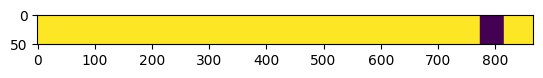

In [38]:
plt.imshow(full_att_4d[0,0].detach().cpu().numpy())

In [41]:
suffix_out.shape

torch.Size([1, 51, 1024])

In [40]:
action_out.shape

torch.Size([1, 50, 1024])

In [42]:
pt_model.action_out_proj

Linear(in_features=1024, out_features=32, bias=True)

In [46]:
np.where(np.abs(np.diff(full_att_4d[0,0,0,:].detach().cpu().numpy())))

(array([773, 815, 816]),)

## 8. Compare Against Reference

In [35]:
# Apply the same output transforms to our manually denoised actions
outputs_manual = {
    "state": np.asarray(inputs_pt["state"][0].cpu()),
    "actions": x_t[0].cpu().numpy(),
}
outputs_manual = policy._output_transform(outputs_manual)

max_diff = np.max(np.abs(result_ref["actions"] - outputs_manual["actions"]))
print(f"Max diff vs reference: {max_diff:.2e}")
print(f"All close (atol=1e-4): {np.allclose(result_ref['actions'], outputs_manual['actions'], atol=1e-4)}")
print(f"All close (atol=1e-3): {np.allclose(result_ref['actions'], outputs_manual['actions'], atol=1e-3)}")

Max diff vs reference: 8.73e-04
All close (atol=1e-4): False
All close (atol=1e-3): True


## 9. Compare: Using denoise_step (cleaner API)

The PyTorch model has a nice self-contained `denoise_step` method.
Let's verify it matches our manual loop, then use it going forward.

In [36]:
# Re-run using the model's denoise_step method
x_t_v2 = noise_pt.clone()
t_v2 = 1.0

with torch.no_grad():
    for step in range(num_steps):
        timestep = torch.tensor(t_v2, dtype=torch.float32, device=device).expand(1)
        v_t = pt_model.denoise_step(
            state, prefix_pad_masks, kv_cache, x_t_v2, timestep
        )
        x_t_v2 = x_t_v2 + dt * v_t
        t_v2 += dt

diff_v2 = (x_t_v2 - x_t).abs().max().item()
print(f"Max diff (manual loop vs denoise_step): {diff_v2:.2e}")

Max diff (manual loop vs denoise_step): 0.00e+00


## 10. Plot Predicted vs Ground Truth Actions

In [37]:
predicted_actions = outputs_manual["actions"]

In [38]:
# Gather ground truth actions for the next action_horizon frames
action_horizon = predicted_actions.shape[0]
n_gt = min(action_horizon, len(episode) - FRAME_IDX)

gt_actions = np.array([episode[FRAME_IDX + t]["action"] for t in range(n_gt)])
print(f"Ground truth actions: {gt_actions.shape}")
print(f"Predicted actions: {predicted_actions.shape}")

Ground truth actions: (50, 14)
Predicted actions: (50, 14)


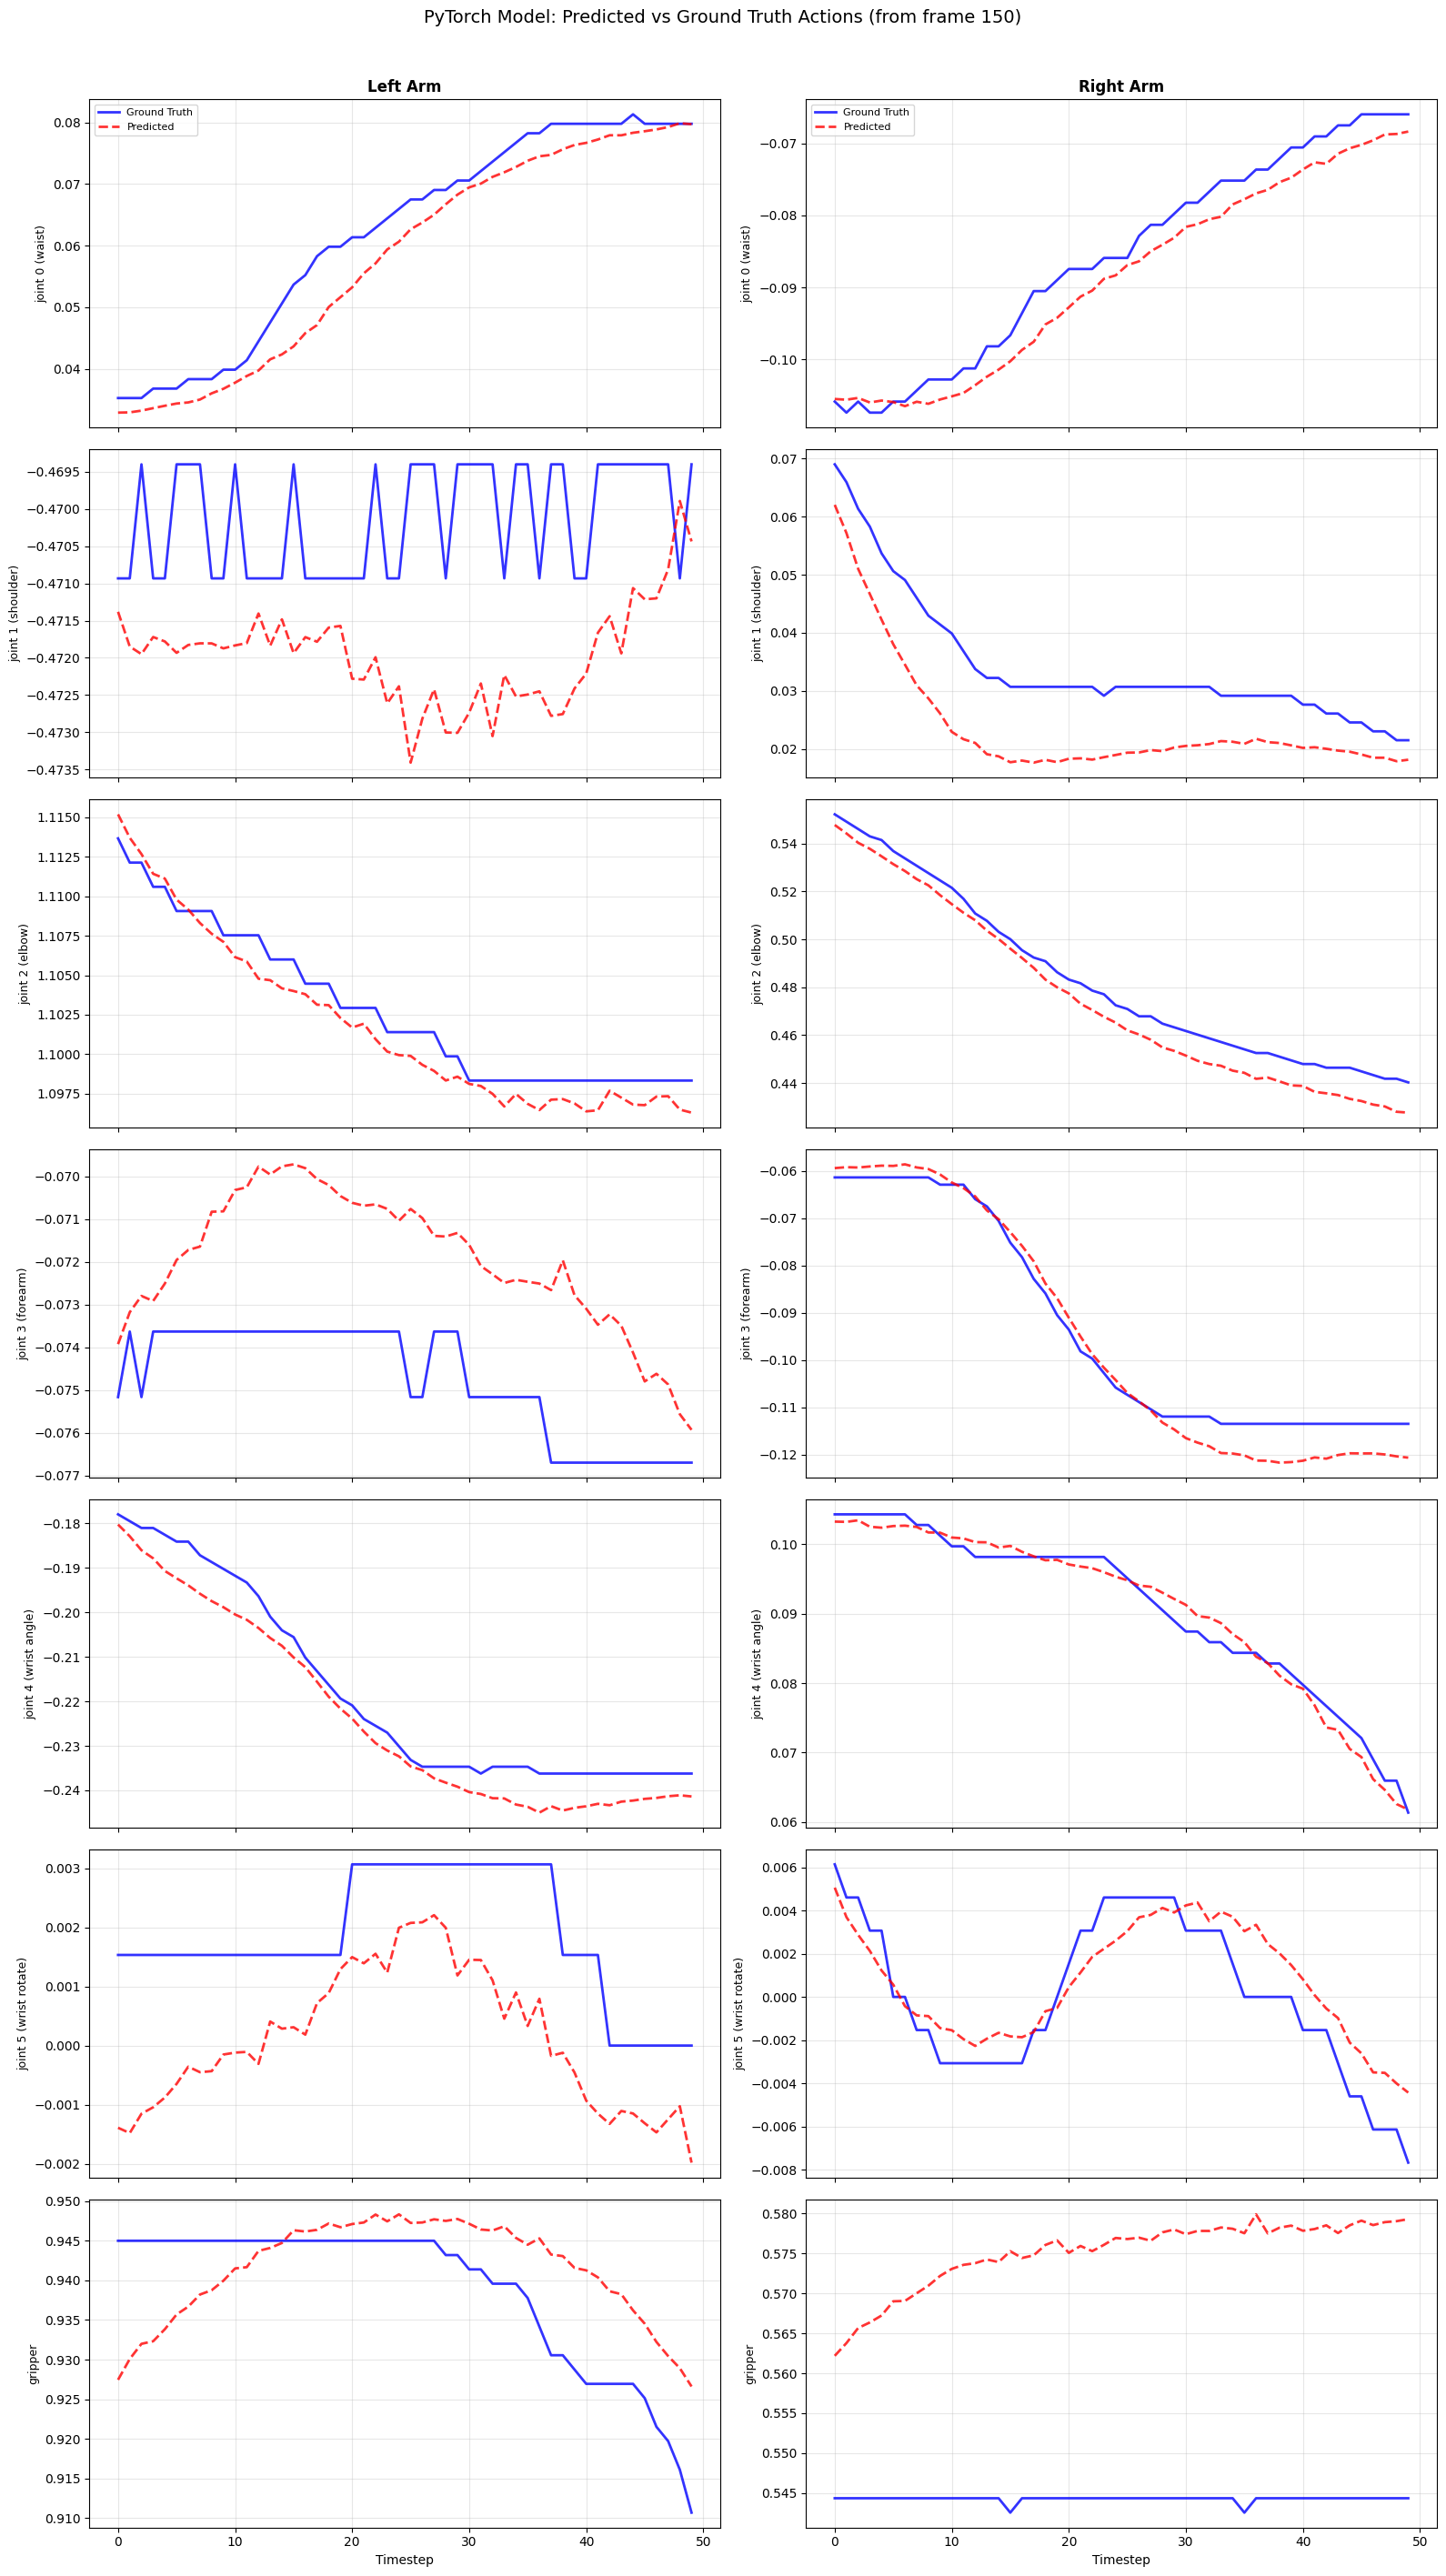

In [39]:
# Plot predicted vs ground truth for each joint
fig, axes = plt.subplots(7, 2, figsize=(16, 28), sharex=True)
time_steps = np.arange(n_gt)

for arm_idx, arm_name in enumerate(["Left", "Right"]):
    offset = arm_idx * 7
    for joint_idx in range(7):
        ax = axes[joint_idx, arm_idx]
        dim = offset + joint_idx
        
        ax.plot(time_steps, gt_actions[:n_gt, dim], 'b-', linewidth=2, label='Ground Truth', alpha=0.8)
        ax.plot(time_steps, predicted_actions[:n_gt, dim], 'r--', linewidth=2, label='Predicted', alpha=0.8)
        
        ax.set_ylabel(joint_labels[dim].replace(f"{arm_name[0]} ", ""), fontsize=9)
        ax.grid(True, alpha=0.3)
        if joint_idx == 0:
            ax.set_title(f"{arm_name} Arm", fontsize=12, fontweight='bold')
            ax.legend(fontsize=8)
        if joint_idx == 6:
            ax.set_xlabel("Timestep")

plt.suptitle(f"PyTorch Model: Predicted vs Ground Truth Actions (from frame {FRAME_IDX})", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 11. Bonus: Hook Into Individual Layers

This is the main payoff of switching to PyTorch — we can register forward hooks
on any layer and capture activations as they flow through the transformer.

In [26]:
# Register hooks on every layer of both experts
activations = {}
hooks = []

def make_hook(name):
    def hook_fn(module, inp, out):
        # Store detached copies to avoid memory issues
        if isinstance(out, torch.Tensor):
            activations[name] = out.detach().cpu()
        elif isinstance(out, tuple) and len(out) > 0:
            activations[name] = out[0].detach().cpu() if isinstance(out[0], torch.Tensor) else str(type(out[0]))
    return hook_fn

# Hook PaliGemma layers (prefix expert)
pali_layers = pt_model.paligemma_with_expert.paligemma.language_model.layers
for i, layer in enumerate(pali_layers):
    h = layer.register_forward_hook(make_hook(f"pali_layer_{i}"))
    hooks.append(h)

# Hook action expert layers
expert_layers = pt_model.paligemma_with_expert.gemma_expert.model.layers
for i, layer in enumerate(expert_layers):
    h = layer.register_forward_hook(make_hook(f"expert_layer_{i}"))
    hooks.append(h)

print(f"Registered {len(hooks)} hooks")
print(f"  PaliGemma layers: {len(pali_layers)}")
print(f"  Action expert layers: {len(expert_layers)}")

Registered 36 hooks
  PaliGemma layers: 18
  Action expert layers: 18


In [27]:
# Run one denoising step and capture activations
activations.clear()

with torch.no_grad():
    timestep = torch.tensor([1.0], dtype=torch.float32, device=device)
    v_t_hooked = pt_model.denoise_step(
        state, prefix_pad_masks, kv_cache, noise_pt, timestep
    )

print("Captured activations:")
for name, act in sorted(activations.items()):
    if isinstance(act, torch.Tensor):
        print(f"  {name}: {act.shape}, dtype={act.dtype}")
    else:
        print(f"  {name}: {act}")

Captured activations:
  expert_layer_0: torch.Size([1, 51, 1024]), dtype=torch.bfloat16
  expert_layer_1: torch.Size([1, 51, 1024]), dtype=torch.bfloat16
  expert_layer_10: torch.Size([1, 51, 1024]), dtype=torch.bfloat16
  expert_layer_11: torch.Size([1, 51, 1024]), dtype=torch.bfloat16
  expert_layer_12: torch.Size([1, 51, 1024]), dtype=torch.bfloat16
  expert_layer_13: torch.Size([1, 51, 1024]), dtype=torch.bfloat16
  expert_layer_14: torch.Size([1, 51, 1024]), dtype=torch.bfloat16
  expert_layer_15: torch.Size([1, 51, 1024]), dtype=torch.bfloat16
  expert_layer_16: torch.Size([1, 51, 1024]), dtype=torch.bfloat16
  expert_layer_17: torch.Size([1, 51, 1024]), dtype=torch.bfloat16
  expert_layer_2: torch.Size([1, 51, 1024]), dtype=torch.bfloat16
  expert_layer_3: torch.Size([1, 51, 1024]), dtype=torch.bfloat16
  expert_layer_4: torch.Size([1, 51, 1024]), dtype=torch.bfloat16
  expert_layer_5: torch.Size([1, 51, 1024]), dtype=torch.bfloat16
  expert_layer_6: torch.Size([1, 51, 1024]), d

In [28]:
# Clean up hooks when done
for h in hooks:
    h.remove()
hooks.clear()
print("Hooks removed")

Hooks removed
